In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

## **Load Dataset**

In [10]:
df = pd.read_csv(
    r"C:\Users\Admin\Downloads\e_waste_cleaned_recoverable.csv")
df.head()

,Item,Category,Gold,Silver,Platinum,Rhodium,Nickel,Tin,Lithium,Aluminum,Carbon,Profit ($),Total_Value,Recoverable
0,iPhone 11,Cat3,3.58,2.95,1.73,8.92,1.91,1.01,1.82,1.27,9.51,270.34,1747.586811,1
1,Toaster,Cat2,7.21,4.31,6.21,5.63,9.59,7.65,0.51,3.03,4.22,689.75,1827.215202,1
2,Speaker,Cat4,8.91,5.09,2.42,7.70,1.09,1.49,7.42,3.63,8.83,570.43,1946.945103,1
3,Microwave Oven,Cat2,2.62,3.84,2.98,7.66,9.41,2.25,7.84,6.18,6.36,290.78,1595.124886,0
4,Air Conditioner,Cat1,3.47,3.89,6.20,4.35,5.07,8.65,8.62,0.82,5.53,505.16,1395.768663,0


In [28]:
X = df.drop(columns=["Item", "Category", "Recoverable", "Profit ($)", "Total_Value"])
y = df["Recoverable"]

## **Train Test Split**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## **Random Forest Classifier**

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred = rf_model.predict(X_test)

## **Accuracy**

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.9785


In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1296   11]
 [  32  661]]


## **Feature Importance**

In [36]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Rhodium     0.607896
Platinum    0.176379
Gold        0.123903
Aluminum    0.016295
Nickel      0.015620
Tin         0.015357
Carbon      0.015215
Lithium     0.014864
Silver      0.014470
dtype: float64


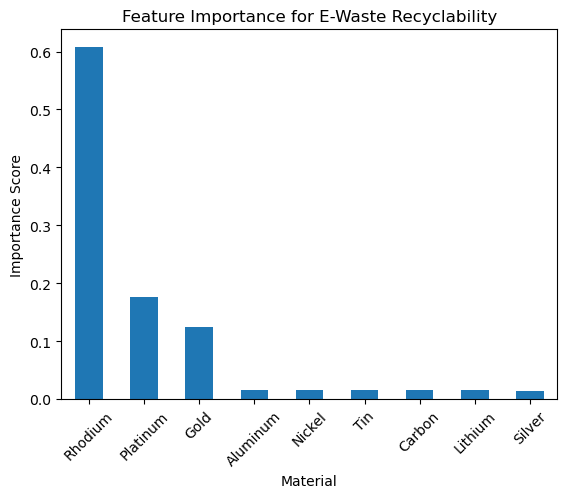

In [37]:
feature_importance.plot(kind="bar")

plt.title("Feature Importance for E-Waste Recyclability")
plt.xlabel("Material")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)
plt.show()